In [1]:
import numpy as np
import random
import torch
# Define a fixed seed value
SEED = 1

# 1. Set the Python built-in random module's seed
random.seed(SEED)

# 2. Set the NumPy random seed
np.random.seed(SEED)

# 3. Set the PyTorch seed (for both CPU and GPU)
torch.manual_seed(SEED)# Define a fixed seed value
print(torch.cuda.is_available())

True


In [2]:
import time
start_time_total = time.time()

In [3]:
# from scipy.linalg import expm, sinm, cosm
from sklearn.model_selection import train_test_split
import networkx as nx
from numpy import linalg as LA
from scipy import sparse
import matplotlib.pyplot as plt
import toponetx as tnx
import torch.nn.functional as F
import os
import itertools

from Util_functions import generate_complex, plot_complex, normalize_laplacian, laplacian_to_incidence
from Utils_models import COSIMO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
import scipy
from scipy import sparse

def get_evals_evecs(L, k):
    L_sparse = sparse.coo_matrix(L.cpu())

    evals, evecs = scipy.sparse.linalg.eigsh(L_sparse, k=k, ncv=4*k, return_eigenvectors=True)

    evals=torch.tensor(evals.real).to(device)
    evecs=torch.tensor(evecs.real).to(device)

    return evals, evecs 

In [5]:
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

In [6]:
import numpy as np

def add_noise_with_snr(matrix, snr_db):
    """
    Add noise to a matrix to achieve a specified SNR.

    Parameters:
        matrix (numpy.ndarray): The original signal matrix.
        snr_db (float): Desired Signal-to-Noise Ratio in dB.

    Returns:
        noisy_matrix (numpy.ndarray): The matrix with added noise.
    """
    # Calculate signal power
    signal_power = np.mean(np.power(matrix, 2))
    
    # Calculate noise power from desired SNR
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    
    # Generate noise
    noise = np.random.normal(scale=np.sqrt(noise_power), size=matrix.shape)
    
    # Add noise to the matrix
    noisy_matrix = matrix + noise
    
    return noisy_matrix

# Example usage
# Create a sample matrix (e.g., a 5x5 matrix of ones)
matrix = np.ones((5, 3))

# Specify desired SNR in dB
desired_snr_db = -10  # 20 dB

# Add noise to the matrix
noisy_matrix = add_noise_with_snr(matrix, desired_snr_db)

print("Original Matrix:")
print(matrix)
print("\nNoisy Matrix:")
print(noisy_matrix)

Original Matrix:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Noisy Matrix:
[[ 6.13663106 -0.93454364 -0.67022573]
 [-2.3930247   3.73665921 -6.27810441]
 [ 6.51757926 -1.40714758  2.00889021]
 [ 0.21142163  5.62359127 -5.51473694]
 [-0.01957272 -0.21448651  4.58529378]]


In [7]:
import time
start_time = time.time()
lr = 1e-2


In [8]:
MaxGen = 30
n = 30
kk = 20
t_d = 1
t_u = 2
FF = 1
epochs = 100
SNR_B1_List = [-5, 0, 10, 20]
SNR_B2_List = [-5, 0, 10, 20]

MSE_SNRs = np.zeros((len(SNR_B1_List), len(SNR_B2_List), MaxGen))

for gen in range (MaxGen):

    sc, coords = generate_complex(n)
    B1 = sc.incidence_matrix(1).todense()
    B2 = sc.incidence_matrix(2).todense()

    L0 = sc.hodge_laplacian_matrix(0).todense()
    N0 = L0.shape[0]
    L1 = torch.tensor(sc.hodge_laplacian_matrix(1).todense()).to(device)
    N1 = L1.shape[0]
    L2 = sc.hodge_laplacian_matrix(2).todense()
    N2 = L2.shape[0]
    X0_0 = torch.randn(N0, FF).to(device)
    # X0_0 = X0_0/LA.linalg.norm(X0_0, ord=2)
    X1_0 = torch.randn(N1, FF).to(device)
    # X1_0 = X1_0/LA.linalg.norm(X1_0, ord=2)
    X2_0 = torch.randn(N2, FF).to(device)
    # X2_0 = X2_0/LA.linalg.norm(X2_0, ord=2)
    # plt.figure()
    # plot_complex(sc, coords)
    
    
    for i, SNR_B1 in enumerate(SNR_B1_List):
        
        B1_noisy = torch.tensor(add_noise_with_snr(B1, SNR_B1)).to(device).to(torch.float32)
              
        L0_d = 0
        L0_u_noisy = B1_noisy@B1_noisy.T
        
        L1_d_noisy = B1_noisy.T@B1_noisy
        L1_d_clean = torch.tensor(B1.T@B1).to(device)

        X0_u_0 = B1_noisy@X1_0
        X1_d_0 = B1_noisy.T@X0_0

        for j, SNR_B2 in enumerate(SNR_B2_List):
            
            # save the model
            model_path = r'./model_exp'
            model_save_path = './loss_files/'
            if not os.path.exists(model_save_path):
                os.makedirs(model_save_path, exist_ok=True)
            
            # Define the directory and file path
            
            losslogf = open("./loss_files/_%dSNR_B1_%dSNR_B2.txt","w")
            time_measure = open("./loss_files/time_%dSNR_B1_%dSNR_B2.txt"%(SNR_B1,SNR_B2),"w")

            best_val = 1e6

            B2_noisy = torch.tensor(add_noise_with_snr(B2, SNR_B2)).to(device).to(torch.float32)      

            L1_u_noisy = B2_noisy@B2_noisy.T
            L1_u_clean = torch.tensor(B2@B2.T).to(device)
            
            
            L2_d_noisy = B2_noisy.T@B2_noisy
            L2_u = 0
            
            
            X1_u_0 = B2_noisy@X2_0
            X2_d_0 = B2_noisy.T@X1_0

            X0_noisy = torch.tanh(torch.linalg.matrix_exp(-t_u*L0_u_noisy)@X0_0 + torch.linalg.matrix_exp(-t_u*L0_u_noisy)@X0_u_0)            
            
            X1_noisy = torch.tanh(torch.linalg.matrix_exp(-t_d*L1_d_noisy)@X1_d_0 + torch.linalg.matrix_exp(-t_d*L1_d_noisy)@X1_0 + torch.linalg.matrix_exp(-t_u*L1_u_noisy)@X1_0 + torch.linalg.matrix_exp(-t_u*L1_u_noisy)@X1_u_0)
            X1_clean = torch.tanh(torch.linalg.matrix_exp(-t_d*L1_d_clean)@X1_d_0 + torch.linalg.matrix_exp(-t_d*L1_d_clean)@X1_0 + torch.linalg.matrix_exp(-t_u*L1_u_clean)@X1_0 + torch.linalg.matrix_exp(-t_u*L1_u_clean)@X1_u_0)
        
            train_indices, test_indices = train_test_split(np.arange(X1_clean.shape[0]), test_size=0.15, random_state=42)
            train_indices, val_indices = train_test_split(np.arange(len(train_indices)), test_size=0.15, random_state=42)
        
            X2_noisy = torch.tanh(torch.linalg.matrix_exp(-t_d*L2_d_noisy)@X2_0 + torch.linalg.matrix_exp(-t_d*L2_d_noisy)@X2_d_0)

            evals_0, evecs_0 = get_evals_evecs(L0_u_noisy, kk)
            evals_1l, evecs_1l = get_evals_evecs(L1_d_noisy, kk)
            evals_1u, evecs_1u = get_evals_evecs(L1_u_noisy, kk)
            evals_2, evecs_2 = get_evals_evecs(L2_d_noisy, kk)
            
            single_t = False
            model = COSIMO(F_in=1, F_intermediate=[4], F_out=1, b1=B1_noisy, b2=B2_noisy,
                        evals_0=evals_0, evecs_0=evecs_0, evals_1l=evals_1l,
                        evecs_1l=evecs_1l, evals_1u=evals_1u, evecs_1u=evecs_1u, evals_2=evals_2, evecs_2=evecs_2,
                        sigma=torch.tanh, model_name='sccnn_edge', single_t=single_t)
            # define the loss and optimizer 
            optimizer = torch.optim.Adam(itertools.chain(model.parameters()), lr =lr) 

            # pred = MLPPredictor(h_feats=1) # the number of the features of the output of the scnn model 
            model.to(device)
            # pred.to(device)

            f_input = (X0_0.to(device), X1_0.to(device), X2_0.to(device))

            for e in range(epochs):
                '''
                forward
                ''' 
                start_time = time.time()
                
                X0_noisy_pred,X1_noisy_pred,X2_noisy_pred = model(f_input)
                '''
                here we need to preprocess, i.e., reorganizing the matrix of edge features h for prediction input, in the form of, e.g., train_pos_i, train_pos_, train_pos_k, for each triangle, 
                '''

                # loss = F.binary_cross_entropy_with_logits(scores,labels)
                
                '''compute the loss'''
                loss = F.mse_loss(X1_noisy_pred[train_indices], X1_clean[train_indices], reduction='mean')
                # loss = compute_loss(train_pos_score, train_neg_score, labels)

                losslogf.write("epoch %d, loss: %f\n" %(e, loss.item()))
                losslogf.flush()

                '''val'''
                with torch.no_grad():
                    '''
                    here we need to preprocess, i.e., reorganizing the matrix of edge features h for prediction input, in the form of, e.g., train_pos_i, train_pos_, train_pos_k, for each triangle, 
                    '''

                    # loss = F.binary_cross_entropy_with_logits(scores,labels)
                    
                    '''compute the loss'''
                    vloss = F.mse_loss(X1_noisy_pred[val_indices], X1_clean[val_indices], reduction='mean')                       
                    test_loss = F.mse_loss(X1_noisy_pred[test_indices], X1_clean[test_indices], reduction='mean')
                    
                    if vloss < best_val:
                        best_val = vloss
                        # print('curent epoch:', e)
                        torch.save({'model': model.state_dict()},model_save_path+'model.pth')
                        losslogf.write("model updated at epoch %d \n" %(e))
                    if e%10==0:
                        print('gen {}, SNR_B1: {}, SNR_B2: {}, epoch {},\n train loss: {}, val loss: {}'.format(gen, SNR_B1, SNR_B2, e, loss, vloss))    
                    
                losslogf.write("epoch %d, \n train loss: %f, val loss: %f" %(e, loss.item(), vloss))
                losslogf.flush()
                
                '''
                backward
                '''
                optimizer.zero_grad()
                loss.backward()
                optimizer.step() 
                end_time = time.time()
                time_measure.write(str(end_time-start_time)+'\n')


            '''
            testing
            '''       

            model.load_state_dict(torch.load(model_save_path+'model.pth',map_location=device)['model'],strict=False)

            X0_noisy_pred,X1_noisy_pred,X2_noisy_pred = model(f_input)

            with torch.no_grad():
                vloss = F.mse_loss(X1_noisy_pred[val_indices], X1_clean[val_indices], reduction='mean')                       
                test_loss = F.mse_loss(X1_noisy_pred[test_indices], X1_clean[test_indices], reduction='mean')
                MSE_SNRs[i, j, gen] = test_loss
                print('+++ test loss: ',test_loss, ', val loss: ', vloss)

            # losslogf.close()
    
    
    

sccnn_edge
created SCCNN-Cont layers
created SCCNN-Cont layers
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 0,
 train loss: 1.513783574104309, val loss: 1.3444167375564575
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 10,
 train loss: 0.5692811012268066, val loss: 0.4468901753425598
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 20,
 train loss: 0.2994195818901062, val loss: 0.27550074458122253
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 30,
 train loss: 0.3134916424751282, val loss: 0.26804614067077637
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 40,
 train loss: 0.2839936316013336, val loss: 0.283951073884964
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 50,
 train loss: 0.26686739921569824, val loss: 0.28019604086875916
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 60,
 train loss: 0.257732093334198, val loss: 0.27667781710624695
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 70,
 train loss: 0.253692626953125, val loss: 0.28771254420280457
gen 0, SNR_B1: -5, SNR_B2: -5, epoch 80,
 train loss: 0.2489948719739914, val loss: 0.2888649106025696
gen 0, SN

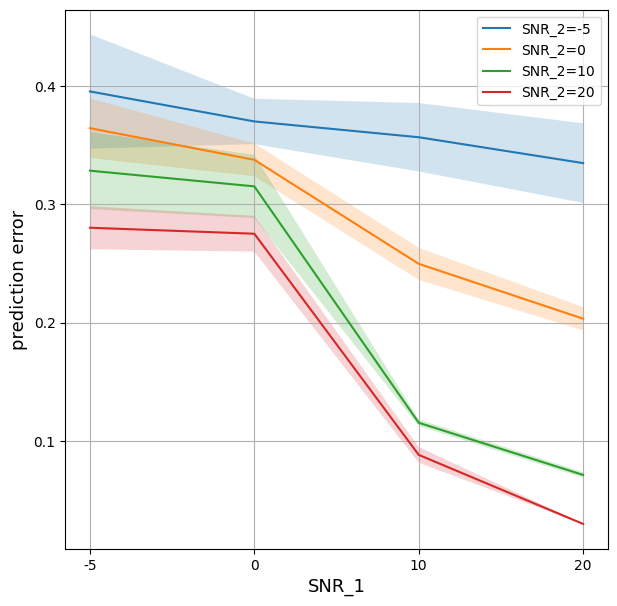

In [9]:
# np.savez('Satbility_Analysis.npz', SNR_B2_List=SNR_B2_List, MSE_SNRs=MSE_SNRs)
# data = np.load('Satbility_Analysis.npz')
# SNR_B2_List = data['SNR_B2_List']
# MSE_SNRs = data['MSE_SNRs']

import matplotlib.pyplot as plt

SNR_list = SNR_B2_List
p_list = range(len(SNR_B2_List))

Err_Mat_CGPGNN = MSE_SNRs

fig = plt.figure(figsize=(7,7))
for idx_SNR, SNR_2 in enumerate(SNR_list):
    Err_Mat_CGPGNN_temp = np.squeeze(Err_Mat_CGPGNN[:, idx_SNR, :])
    Mean_error_CGPGNN = np.mean(Err_Mat_CGPGNN_temp, axis=1)
    Mean_error_CGPGNN_var = 0.8*np.var(Err_Mat_CGPGNN_temp, axis=1)*1
    plt.plot(p_list, Mean_error_CGPGNN, label='SNR_2='+str(SNR_2))
    plt.fill_between(p_list, Mean_error_CGPGNN - Mean_error_CGPGNN_var, 
                     Mean_error_CGPGNN + Mean_error_CGPGNN_var, alpha=0.2)
    plt.xlabel('SNR_1', fontsize=13)
    plt.ylabel('prediction error', fontsize=13)    
plt.legend(fontsize=10)  
plt.grid(True)
plt.xticks(p_list, ['-5', '0', '10', '20'])
    
plt.show() 

In [10]:
finish_time_total = time.time()
print("--- %s minutes ---" % (round((finish_time_total - start_time_total)/60, 2)))

--- 3.25 minutes ---
